<img src="https://i.ibb.co/93sNcdhp/Logo-pmat-color.png" align="right" width="150">

<br>

# **Intervalos de Confianza para la Media**

## **Objetivos**

- Comprender el concepto de *intervalo de confianza (IC)* para la media y su interpretación.
- Calcular intervalos de confianza para la media poblacional bajo distintos supuestos (σ conocida y desconocida).
- Analizar cómo influyen el tamaño de la muestra y el nivel de confianza en el ancho del intervalo.
- Aplicar los intervalos de confianza en distintos contextos (ciencia, comercio, educación y salud).

💡 *Recuerda*: un intervalo de confianza describe un procedimiento que captura el verdadero parámetro un cierto porcentaje de veces al repetir el muestreo, no es una garantía sobre esta muestra específica.


## **Recordatorio clave**

| Situación                                    | Fórmula para el IC de la media |
|---------------------------------------------|--------------------------------|
| **σ poblacional desconocida**                | $ \bar{x} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}} $ |
| **σ poblacional conocida**                   | $ \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}} $ |


- **$n$**: tamaño de la muestra  
- **$\bar{x}$**: media muestral  
- **$s$**: desviación estándar muestral  
- **$\sigma$**: desviación estándar poblacional conocida  
- **$z$** o **$t$**: valor crítico según nivel de confianza elegido

💡 **Decisión rápida:**  
- Si la desviación estándar poblacional ($\sigma$) es desconocida y la muestra es pequeña ($n < 30$), usar distribución $t$ de Student.

- Si la desviación estándar poblacional ($\sigma$) es conocida o la muestra es grande ($n ≥ 30$), usar distribución $z$.

# **Actividad 1 — Estimación de la temperatura promedio de un laboratorio**

En un laboratorio de biotecnología que manipula microorganismos sensibles, mantener la temperatura ambiente dentro de un rango controlado es crucial para la estabilidad de los cultivos y la seguridad del personal. Durante una jornada de trabajo matutina se registraron 25 mediciones de temperatura en distintos puntos del laboratorio, ya que el sistema de climatización había presentado variaciones y se requería verificar si las condiciones se mantenían estables.

A continuación, se muestran las mediciones de temperatura (°C) registradas:

<center>

|  |  |  |  |  |
|------|------|------|------|------|
| 22.1 | 22.3 | 22.7 | 21.9 | 22.5 |
| 22.8 | 22.0 | 22.4 | 21.8 | 22.3 |
| 22.6 | 22.5 | 22.1 | 22.4 | 22.7 |
| 22.8 | 22.0 | 22.2 | 22.1 | 22.5 |
| 22.3 | 22.7 | 22.6 | 22.4 | 22.5 |

In [131]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

1. Calcula la *media* y la *desviación estándar muestral* de los datos de temperatura.  

In [132]:
temperatura = [
    22.1 , 22.3 , 22.7 , 21.9 , 22.5,
    22.8 , 22.0 , 22.4 , 21.8 , 22.3,
    22.6 , 22.5 , 22.1 , 22.4 , 22.7,
    22.8 , 22.0 , 22.2 , 22.1 , 22.5,
    22.3 , 22.7 , 22.6 , 22.4 , 22.5
]

media = np.mean(temperatura)
desv = np.std(temperatura, ddof=1)

print(f'La media muestral es {media:.2f}°C y la desviación estándar es {desv:.2f}°C')

La media muestral es 22.37°C y la desviación estándar es 0.29°C


2. Construye un *intervalo de confianza al 95%* para la media poblacional usando la distribución *t* de Student.

In [133]:
n = len(temperatura)
se = desv / np.sqrt(n)

ic = st.t.interval(
    confidence=0.95,
    df = n - 1,
    loc = media,
    scale = se
)

ic

(np.float64(22.250207008826603), np.float64(22.4857929911734))

3. ¿Qué significa que el intervalo de confianza tenga un nivel de confianza del 95%?



**Significa que el 95% de los casos en que se repita el muestreo de Temperatura, el promedio poblacional se encontrará en el IC 22.5 a 22.49°C**

4. Interpreta el intervalo de confianza encontrado en un lenguaje comprensible para el responsable del laboratorio.

**Basado en los valores medidos, la temperatura promedio de la sala se estima en 22°C el 95% de las veces**

# **Actividad 2 — Resultados académicos en educación**

En un instituto profesional se busca estimar el promedio final de notas en una asignatura clave con una matrícula de 800 estudiantes. Para tener una primera aproximación sin procesar todos los registros, se tomó una muestra aleatoria de 20 calificaciones finales (escala de 1,0 a 7,0). De estos datos desconoce la desviación estándar poblacional.

Las calificaciones recolectadas son:

<center>

|  |  |  |  |  |  |  |  |  |  |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| 5.1 | 5.4 | 4.8 | 5.2 | 4.9 | 5.5 | 5.0 | 4.7 | 5.3 | 5.1 |
| 5.2 | 5.0 | 5.3 | 5.5 | 4.9 | 5.4 | 5.2 | 5.0 | 5.6 | 5.3 |



1. Calcula la *media* y la *desviación estándar muestral*.

In [134]:
calificaciones = [
    5.1, 5.4, 4.8, 5.2, 4.9, 
    5.5, 5.0, 4.7, 5.3, 5.1, 
    5.2, 5.0, 5.3, 5.5, 4.9, 
    5.4, 5.2, 5.0, 5.6, 5.3
]

media = np.mean(calificaciones)
desv = np.std(calificaciones)

print(f'La media muestral es {media:.2f} y la desviación estándar es {desv:.2f}')

La media muestral es 5.17 y la desviación estándar es 0.24


2. Antes de construir el intervalo, justifica brevemente si usarías $z$ o $t$ y por qué. ¿Qué información sobre la desviación estándar poblacional ($\sigma$) respalda esta decisión?

**Deberiamos de usar *t* debido a que tenemos una cantidad de muestras menor a 30 y ademas de que no conocemos la desviación estándar poblacional**

3. Construye un *intervalo de confianza al 95%* para la media poblacional.

In [135]:
n = len(calificaciones)
ee = desv / np.sqrt(n)

ic = st.t.interval(
    confidence=0.95,
    df=n-1,
    loc = media,
    scale = ee
)

print(f'En el interfalo de confianza del 95% el limite inferior es {ic[0]:.2f} y el limite superior es {ic[1]:.2f}')

En el interfalo de confianza del 95% el limite inferior es 5.06 y el limite superior es 5.28


# **Mini diagnóstico - Decidir entre $t$ y $z$**

Antes de avanzar, reflexiona sobre qué distribución corresponde usar en cada escenario.

No es necesario calcular intervalos, solo decidir qué distribución corresponde usar ($t$ o $z$) y justificar brevemente tu elección.

*Considera*: tamaño de la muestra, conocimiento de σ y forma de la distribución.


**Escenarios:**
1. Se tiene una muestra de 15 mediciones de temperatura, con desviación estándar poblacional ($\sigma$) desconocida, distribución aproximadamente normal.



2. Se tienen los datos del tiempo de crecimiento de 50 plantas silvestres donde la desviación estándar poblacional ($\sigma$) es conocida y los datos son aproximadamente normales.





# **Actividad 3 — Efecto del tamaño de muestra y del nivel de confianza**

En esta actividad explorarás cómo cambian los intervalos de confianza cuando varía el tamaño de la muestra y el nivel de confianza.

Trabaja con los resultados de un examen nacional de matemáticas con media 500 puntos y desviación estándar 100 puntos, asumiendo que los puntajes se distribuyen normalmente.

### **Parte A: Efecto del tamaño muestral**

1. Genera un conjunto de 100 puntajes simulados que sigan una distribución normal

In [136]:
np.random.seed(20260326)
puntajes = np.random.normal(
    500, # Media
    100, # Desv.
    100 # Cantidad muestras
)

2. Calcula los intervalos de confianza al $95\%$ para muestras de tamaños $n=10,30,100$. Luego, determina la amplitud de cada intervalo.

In [137]:
dicc = {}
for i in [10, 30, 100]:
    muestra = np.random.choice(puntajes, i)
    
    ic = st.norm.interval(
        confidence=0.95,
        loc=muestra.mean(),
        scale=muestra.std(ddof=1) / np.sqrt(i)
    )
    
    dicc[f'muestra_{i}'] = {'LI': ic[0], 'LS': ic[1]}
    
    print(f'El IC al 95% para {i} muestras es: [{ic[0]:.2f}, {ic[1]:.2f}]')

pd.DataFrame(dicc).T
muestra_30 = np.random.choice(puntajes,30)

El IC al 95% para 10 muestras es: [507.69, 683.97]
El IC al 95% para 30 muestras es: [404.44, 490.97]
El IC al 95% para 100 muestras es: [461.55, 505.71]


**Reflexiona:**
* ¿Qué ocurre con el intervalo al aumentar el tamaño de la muestra?
* ¿Qué puedes concluir sobre la precisión de la estimación?

### **Parte B: Efecto del nivel de confianza**

3. Usando una muestra fija de tamaño $n = 30$, calcula los intervalos al $90\%$, $95\%$ y $99\%$ de confianza y su amplitud.

In [138]:
media = muestra_30.mean()
desv = muestra_30.std(ddof=1)
n = len(muestra_30)
ee = desv /np.sqrt(n)

dicc = {}

for conf in [0.90, 0.95, 0.99]:
    valor = 'IC ' + str(conf*100) + '%'
    ic = st.norm.interval(confidence=conf, loc=media, scale=ee)
    dicc[valor] = {'LI': ic[0], 'LS': ic[1], 'Amplitud': ic[1] - ic[0]}
                   
pd.DataFrame(dicc).T


,LI,LS,Amplitud
IC 90.0%,476.591199,540.559799,63.968600
IC 95.0%,470.463855,546.687143,76.223288
IC 99.0%,458.488308,558.662689,100.174381


**Reflexiona**
* ¿Qué ocurre con el intervalo al aumentar el nivel de confianza?
* ¿Qué implicancia tiene esto en términos de *“seguridad”* y *“precisión”*?

# **Actividad 4 — Satisfacción de clientes en un comercio electrónico**

Una empresa de venta en línea desea evaluar el nivel de satisfacción de sus clientes para mejorar su servicio postventa. Se tomó una muestra aleatoria de 50 valoraciones de clientes recientes, cada una en una escala de 1 a 10, donde 10 es “muy satisfecho”. Estudios previos de la plataforma sugieren que la desviación estándar poblacional puede asumirse cercana a 1,2 puntos.

En el dataset se presentan los puntajes de satisfacción de la muestra tomada, descargue sus datos **<a href="https://docs.google.com/spreadsheets/d/1Y5-tGT4tJ6xh7g_HPy6yTNgQuP0-IX1w/export?format=xlsx">aquí</a>**:



1. Calcula la *media muestral* de satisfacción.

In [139]:
df = pd.read_excel('G2_A4_valoraciones_clientes.xlsx')
var = 'valoracion'
media = df[var].mean()

print(f'La media muestral de satisfacción es {media}')

La media muestral de satisfacción es 8.368


2. ¿Qué distribución, $z$ o $t$, correspondería utilizar si tuvieses que estimar la media poblacional de la satisfacción de los clientes mediante un intervalo de confianza? Justifica tu respuesta.

* **Correspondería una distribución Z (normal estandarizada) debido a que tenemos más de 30 datos de tamaño muestral y conocemos $\sigma$**

3. Construye un intervalo de confianza al 90% para la media. ¿Qué indica este intervalo sobre el nivel de satisfacción de los clientes?

In [140]:
n = len(df)
sigma = 1.2
ee = sigma / np.sqrt(n)

ic = st.norm.interval(confidence=0.90, loc=media, scale=ee)

print(f'IC 90% = [ {ic[0]:.2f} ; {ic[1]:.2f} ]')

IC 90% = [ 8.09 ; 8.65 ]


4. Calcula el intervalo al 99% y compara los resultados obtenidos con los del inciso anterior. ¿Qué ocurre con la amplitud del intervalo al aumentar el nivel de confianza?

In [141]:

ic = st.norm.interval(confidence=0.99, loc=media, scale=ee)

print(f'IC 99% = [ {ic[0]:.2f} ; {ic[1]:.2f} ]')

IC 99% = [ 7.93 ; 8.81 ]


# **Actividad 5 — Tiempo promedio de atención en un centro de salud**

En el servicio de urgencias de un centro médico se registraron los tiempos de espera (minutos) de 500 pacientes con el objetivo de evaluar la eficiencia del servicio. Estudios previos indican que la *desviación estándar poblacional* de los tiempos de espera puede asumirse cercana a *5 minutos*.

A continuación, se te proporciona un conjunto de datos con los tiempos de espera de estos 500 pacientes. Descarga el dataset **<a href="https://docs.google.com/spreadsheets/d/1mlz1mRxZzicrxm5tzXa0LPNNqwf9CslA/export?format=xlsx">aquí</a>**.

In [142]:
df = pd.read_excel('G2_A5_tiempos_espera.xlsx')
df.head()

,tiempo_espera_min
0,49.483571
1,46.308678
2,50.238443
3,54.615149
4,45.829233


1. Calcula e interpreta la *media muestral* de los tiempos de espera.  

In [143]:
var = 'tiempo_espera_min'
media = df[var].mean()
print(f'En promedio las epersonas esperan {media:.2f} minutos')

En promedio las epersonas esperan 47.03 minutos


2. Genera un histograma de los tiempos de espera e interpreta brevemente la forma de la distribución. ¿Los tiempos parecen distribuirse de manera aproximadamente normal?

* Basado en el histograma y la curva normal de igual media muestral y desviación estándar

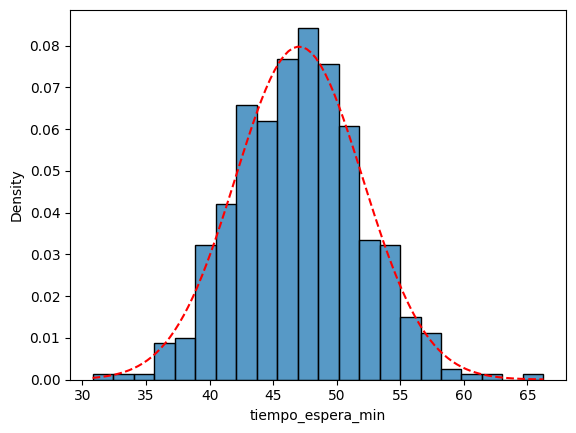

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estimar Curva Normal
x = np.linspace(df[var].min(), df[var].max(), 100)
plt.plot(x, st.norm.pdf(x, media, 5), 'r--')

sns.histplot(df[var], stat='density')
plt.show()

3. Construye un *intervalo de confianza al 99%* para la media poblacional

In [145]:
n = 500
ee = 5 / np.sqrt(n)


ic = st.norm.interval(confidence=0.99, loc=media, scale=ee)
ic

(np.float64(46.458217030826106), np.float64(47.61016291506036))

4. Considerando el intervalo obtenido, ¿cómo podrías comunicar este resultado a la dirección del centro médico?

**El verdadeor valor de la media poblacion de los tiempos de espera de la urgencia se encuentra entre 46.49 min y 47.61 min.**

# **Actividad 6 - Vida útil de ampolletas**

Un fabricante anuncia que sus ampolletas duran en promedio 800 horas, con una desviación estándar conocida de 40 horas.

Se toma una muestra de 25 ampolletas, cuya vida promedio observada es de 780 horas.

Asumiendo que la duración de las ampolletas se distribuye normalmente:

1.	Calcula un intervalo de confianza del 95% para la media poblacional.

In [150]:
ic = st.t.interval(
    confidence=0.95,
    df=25-1,
    loc=780,
    scale=40 / np.sqrt(25)
)
ic

(np.float64(763.4888115069758), np.float64(796.5111884930242))

2. Compara el valor anunciado (800 horas) con el intervalo obtenido. ¿Los datos de la muestra respaldan la afirmación del fabricante?

# **Actividad 7 - Volumen promedio de bebidas**

Un fabricante de máquinas despachadoras de bebidas asegura que sus productos sirven en promedio 240 ml en 99,9% de los casos. Un comprador decide veriﬁcar una de las máquinas, para esto toma una muestra aleatoria de 20 bebidas, obteniendo las siguientes mediciones (en mililitros):

243, 250, 240, 248, 245, 250, 238, 246, 252, 247, 246, 240, 250, 249, 248, 240, 245, 247, 238, 248

Si se supone normalidad en los datos y una conﬁanza de 99,9%, determine si es válida la aﬁrmación del fabricante.

In [153]:
volumen = [243, 250, 240, 248, 245, 250, 238, 246, 252, 247, 246, 240, 250, 249, 248, 240, 245, 247, 238, 248]

n = len(volumen)
media = np.mean(volumen)
desv = np.std(volumen, ddof=1)
ee = desv / np.sqrt(n)

ic = st.t.interval(confidence=0.99, loc=media, scale=ee, df=n-1) 
ic

(np.float64(242.75824372410213), np.float64(248.24175627589787))

# **Actividad de cierre — Aplicación a tu contexto**

Imagina un escenario real de tu área profesional donde quisieras estimar un promedio relevante (ej.: tiempo de atención, puntaje de prueba, ventas, temperatura de proceso, etc.).

1. Describe la variable que estimarías y explica por qué sería útil conocer su promedio.
2. Describe cómo obtendrías una muestra adecuada.
3. Indica si usarías $t$ o $z$ y justifica tu decisión.
4. Elige un nivel de confianza y explica tu decisión, considerando el equilibrio entre qué tan exacto quieres que sea el resultado y qué tan seguro deseas estar de él.
5. ¿Cómo influirían tus elecciones estadísticas en la toma de decisiones dentro del escenario que imaginaste? ¿Qué necesitarías para aumentar la precisión de tus estimaciones?

# **Con este laboratorio aprendiste a:**

* Diferenciar cuándo usar $z$ (desviación estándar poblacional conocida) y cuándo $t$ (desviación estándar poblacional desconocida).
* Identificar cómo el tamaño muestral y el nivel de confianza influyen en el ancho del intervalo.
* Reconocer la utilidad de los intervalos de confianza para estimar parámetros y respaldar decisiones basadas en datos.